# Week 5 — Tiny MLP: neural networks from first principles

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg  
**Author:** Prof. Dr. Philipp Pelz  
**Prerequisites:** Week 1 (NumPy, matplotlib) · Week 2 (noise) · Week 3 (PCA) · Week 4 (regression, GD, validation)  
**Time budget:** ~2 hours for a beginner working steadily

---

## What you will do

1. **Generate** a synthetic materials-property dataset: predict Vickers hardness from grain size and
   processing temperature using the Hall–Petch relationship as the ground truth.
2. **Train a linear baseline** (Ridge regression) and record its test score.
3. **Train an MLP** (`sklearn.neural_network.MLPRegressor`) on the same data and observe that,
   with only 225 training samples, it does NOT yet match the linear baseline on the hand-crafted
   $1/\sqrt{d}$ feature — and understand why.
4. **Visualise** the loss curve, the learned fit, and the comparison.
5. **Exercise:** change the MLP width and activation function and observe the effect on the loss
   curve and test score.

## How to use this notebook

All exercise code cells ship a **working version** with `# (try this yourself)` markers on the key lines.  
**Instructions:** before running those lines, try to write them yourself.  
A separate **Solution** markdown cell follows each exercise with a fenced `python` code block.  
Run `nbconvert --execute` end-to-end at any time — it will always succeed.

---

In [1]:
# --- Cell 1: Install and import ---
# Run this cell first (works on Colab; harmless on a local install)
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "numpy", "matplotlib", "scikit-learn", "scipy", "--quiet"],
    check=True
)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(42)
print("Imports OK — NumPy", np.__version__)

Imports OK — NumPy 1.26.4


## Part 1 — Generate a synthetic materials-property dataset

We simulate a Hall–Petch type dataset:

$$H = H_0 + \frac{k}{\sqrt{d}} + c\,(T - T_0) + \varepsilon$$

where
- $d$ = grain diameter (µm)  
- $T$ = processing temperature (°C)  
- $H$ = Vickers hardness (HV)  
- $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ = measurement noise

The $1/\sqrt{d}$ term is **nonlinear** — a linear model in raw $(d, T)$ will underfit.  
An MLP trained on raw $(d, T)$ must discover the nonlinear transformation without being told —
but with only 225 training samples it does NOT yet match the linear baseline (which is given the
$1/\sqrt{d}$ feature by hand). That gap is the lesson.

> **Design note:** we use $N = 300$ total samples (225 training, 75 test). At this scale the
> small MLP ($R^2 \approx 0.65$) is clearly beaten by the linear model on the hand-crafted
> $1/\sqrt{d}$ feature ($R^2 \approx 0.91$). The introductory-level lesson is that domain
> knowledge beats learned features when $N$ is modest — larger datasets and wider networks
> can eventually close the gap.

In [2]:
# --- Cell 2: Generate synthetic Hall–Petch + temperature dataset ---

N = 300                      # total samples
H0, k, c, T0 = 150, 90, -0.15, 700   # Hall–Petch params
SIGMA_NOISE = 8.0            # measurement noise (HV)

# Raw features
d_all = rng.uniform(0.3, 9.0, N)         # grain size (µm)
T_all = rng.uniform(500, 900, N)          # processing temperature (°C)

# Ground-truth hardness (nonlinear in d)
H_true = H0 + k / np.sqrt(d_all) + c * (T_all - T0)
H_all  = H_true + rng.normal(0, SIGMA_NOISE, N)

# Feature matrices:
#   X_raw:  (d, T) — what we give the MLP
#   X_hand: (1/sqrt(d), T) — hand-crafted feature, what we give the linear model
X_raw  = np.column_stack([d_all, T_all])
X_hand = np.column_stack([1.0 / np.sqrt(d_all), T_all])

print(f"Dataset: {N} samples")
print(f"X_raw.shape  = {X_raw.shape}  (features: [d, T])")
print(f"X_hand.shape = {X_hand.shape} (features: [1/sqrt(d), T])")
print(f"Hardness range: {H_all.min():.0f} – {H_all.max():.0f} HV")
print(f"Noise sigma: {SIGMA_NOISE} HV")

Dataset: 300 samples
X_raw.shape  = (300, 2)  (features: [d, T])
X_hand.shape = (300, 2) (features: [1/sqrt(d), T])
Hardness range: 139 – 311 HV
Noise sigma: 8.0 HV


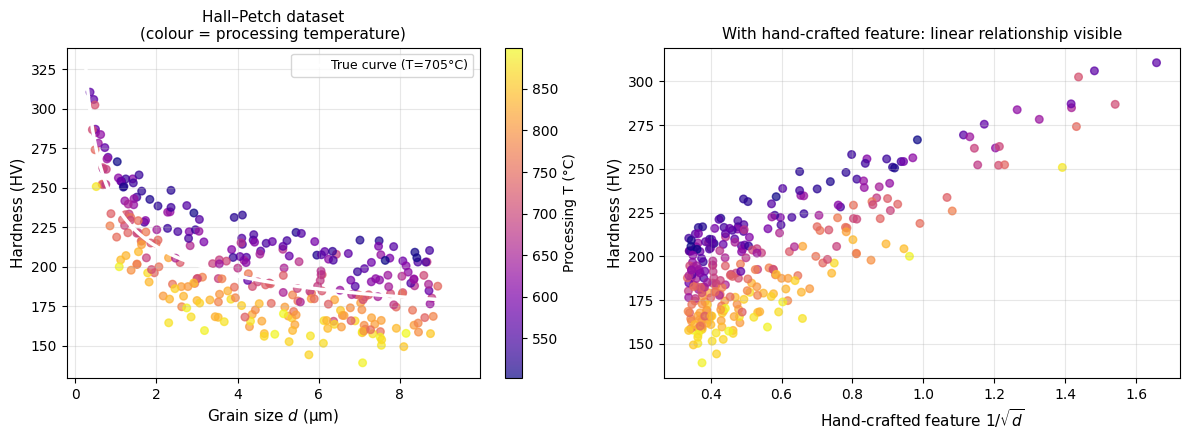

Left: nonlinear in d. Right: approximately linear in 1/sqrt(d).
A linear model on raw d will underfit; on 1/sqrt(d) it works.


In [3]:
# --- Cell 3: Visualise the dataset ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
sc = ax.scatter(d_all, H_all, c=T_all, cmap='plasma', s=30, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Processing T (°C)')
# Overlay true Hall–Petch curve at median temperature
T_med = np.median(T_all)
d_line = np.linspace(0.25, 9.5, 200)
H_line = H0 + k / np.sqrt(d_line) + c * (T_med - T0)
ax.plot(d_line, H_line, 'w-', lw=2.5, label=f'True curve (T={T_med:.0f}°C)')
ax.set_xlabel('Grain size $d$ (µm)', fontsize=11)
ax.set_ylabel('Hardness (HV)', fontsize=11)
ax.set_title('Hall–Petch dataset\n(colour = processing temperature)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(1.0/np.sqrt(d_all), H_all, c=T_all, cmap='plasma', s=30, alpha=0.7)
ax.set_xlabel(r'Hand-crafted feature $1/\sqrt{d}$', fontsize=11)
ax.set_ylabel('Hardness (HV)', fontsize=11)
ax.set_title('With hand-crafted feature: linear relationship visible', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Left: nonlinear in d. Right: approximately linear in 1/sqrt(d).")
print("A linear model on raw d will underfit; on 1/sqrt(d) it works.")

## Part 2 — Train the linear baseline

The linear model gets the hand-crafted feature $1/\sqrt{d}$ (in addition to $T$).  
This encodes the domain knowledge that hardness scales with $d^{-1/2}$.  
We use Ridge regression (small $\ell_2$ regularisation) as the baseline.

In [4]:
# --- Cell 4: Train/test split and fit linear baseline ---

# Use the SAME indices for both the raw and hand-crafted feature matrices
idx = np.arange(N)
idx_tr, idx_te = train_test_split(idx, test_size=0.25, random_state=1)

# Linear model (Ridge) with hand-crafted features
lin_model = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
lin_model.fit(X_hand[idx_tr], H_all[idx_tr])

H_pred_lin_te = lin_model.predict(X_hand[idx_te])
r2_lin  = r2_score(H_all[idx_te], H_pred_lin_te)
mse_lin = mean_squared_error(H_all[idx_te], H_pred_lin_te)

print(f"Linear baseline (Ridge on 1/sqrt(d), T):")
print(f"  Test R²  = {r2_lin:.3f}")
print(f"  Test RMSE = {mse_lin**0.5:.2f} HV")
print()
print(f"Train size: {len(idx_tr)}   Test size: {len(idx_te)}")

Linear baseline (Ridge on 1/sqrt(d), T):
  Test R²  = 0.912
  Test RMSE = 8.63 HV

Train size: 225   Test size: 75


## Part 3 — Train the MLP on raw features

The MLP receives only raw features $(d, T)$ — **no** hand-crafted $1/\sqrt{d}$.  
The network must discover the nonlinear transformation from data alone.

We use `MLPRegressor` from scikit-learn with:
- Two hidden layers of 32 neurons each
- ReLU activation
- Adam optimiser
- `early_stopping=True` to monitor validation loss during training

After training, we inspect the **loss curve** (train and validation MSE per epoch).

In [5]:
# --- Cell 5: Train MLP on raw features ---

mlp_model = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(32, 32),   # two hidden layers, 32 neurons each
        activation='relu',             # ReLU hidden activation
        solver='adam',                 # Adam optimiser
        max_iter=3000,                 # maximum training epochs
        early_stopping=True,           # hold out 10% for validation during training
        validation_fraction=0.10,
        n_iter_no_change=30,           # stop if val loss doesn't improve for 30 epochs
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

mlp_model.fit(X_raw[idx_tr], H_all[idx_tr])

H_pred_mlp_te = mlp_model.predict(X_raw[idx_te])
r2_mlp  = r2_score(H_all[idx_te], H_pred_mlp_te)
mse_mlp = mean_squared_error(H_all[idx_te], H_pred_mlp_te)

n_epochs_trained = len(mlp_model.named_steps['mlp'].loss_curve_)

print(f"MLP (32×32, ReLU, Adam, raw features):")
print(f"  Test R²  = {r2_mlp:.3f}")
print(f"  Test RMSE = {mse_mlp**0.5:.2f} HV")
print(f"  Epochs trained: {n_epochs_trained}")
print()
print(f"Linear baseline R² = {r2_lin:.3f}")
print(f"MLP R²             = {r2_mlp:.3f}")

MLP (32×32, ReLU, Adam, raw features):
  Test R²  = 0.651
  Test RMSE = 17.18 HV
  Epochs trained: 157

Linear baseline R² = 0.912
MLP R²             = 0.651


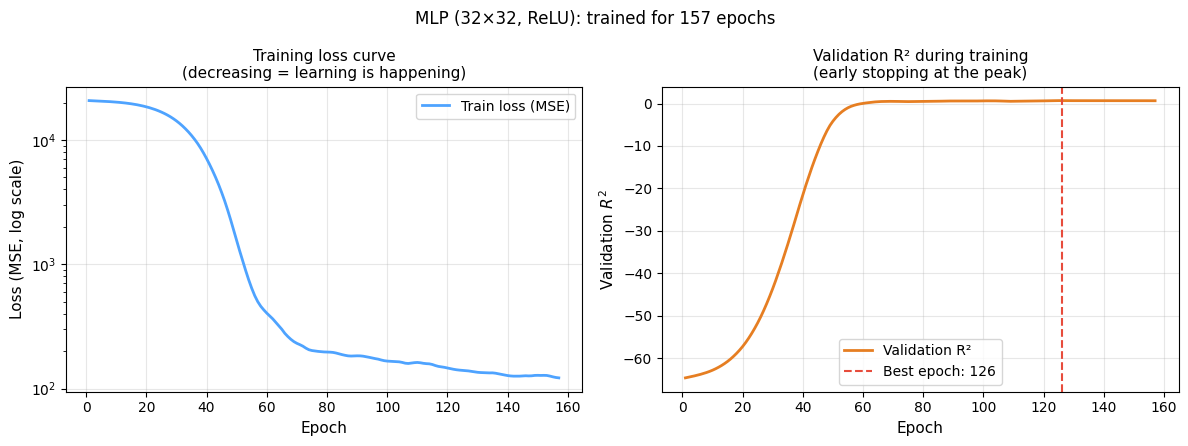

Best validation epoch: 126
Train loss decreases steadily = gradient descent is working.
Validation R² plateaus = early stopping prevented overfitting.


In [6]:
# --- Cell 6: Plot the training loss curve ---

mlp_estimator = mlp_model.named_steps['mlp']
train_loss = mlp_estimator.loss_curve_
val_loss   = mlp_estimator.validation_scores_    # R² on the validation fraction
epochs = np.arange(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.semilogy(epochs, train_loss, color='#4ea3ff', lw=2, label='Train loss (MSE)')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Loss (MSE, log scale)', fontsize=11)
ax.set_title('Training loss curve\n(decreasing = learning is happening)', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, val_loss, color='#e67e22', lw=2, label='Validation R²')
best_epoch = int(np.argmax(val_loss)) + 1
ax.axvline(best_epoch, color='#e74c3c', lw=1.5, linestyle='--',
           label=f'Best epoch: {best_epoch}')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Validation $R^2$', fontsize=11)
ax.set_title('Validation R² during training\n(early stopping at the peak)', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle(f'MLP (32×32, ReLU): trained for {n_epochs_trained} epochs', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Best validation epoch: {best_epoch}")
print("Train loss decreases steadily = gradient descent is working.")
print("Validation R² plateaus = early stopping prevented overfitting.")

## Part 4 — Compare fits visually

Plot predicted vs true hardness for both models and show the fitted curve over the grain-size axis.

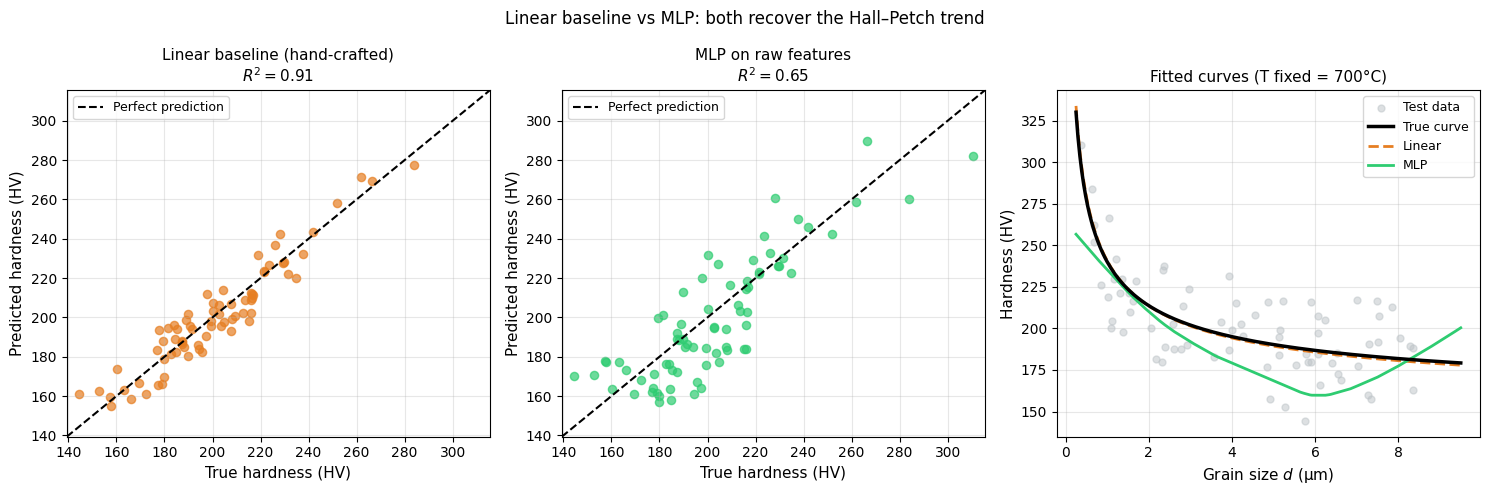

Linear R² = 0.912   MLP R² = 0.651
MLP recovers the nonlinear 1/sqrt(d) shape without being told to.


In [7]:
# --- Cell 7: Visual comparison of linear baseline vs MLP ---

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Parity plots
T_med_te = np.median(T_all[idx_te])
for ax_i, (title, preds, r2, col) in enumerate([
    (f'Linear baseline (hand-crafted)\n$R^2={r2_lin:.2f}$',
     H_pred_lin_te, r2_lin, '#e67e22'),
    (f'MLP on raw features\n$R^2={r2_mlp:.2f}$',
     H_pred_mlp_te, r2_mlp, '#2ecc71'),
]):
    ax = axes[ax_i]
    ax.scatter(H_all[idx_te], preds, color=col, s=35, alpha=0.7)
    lims = [H_all[idx_te].min() - 5, H_all[idx_te].max() + 5]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('True hardness (HV)', fontsize=11)
    ax.set_ylabel('Predicted hardness (HV)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Fitted curve over grain-size axis
ax = axes[2]
T_fixed = 700.0   # fix temperature at 700°C
d_plot = np.linspace(0.25, 9.5, 200)
T_plot = np.full_like(d_plot, T_fixed)
X_raw_plot  = np.column_stack([d_plot, T_plot])
X_hand_plot = np.column_stack([1.0/np.sqrt(d_plot), T_plot])

H_true_plot = H0 + k / np.sqrt(d_plot) + c * (T_fixed - T0)
H_lin_plot  = lin_model.predict(X_hand_plot)
H_mlp_plot  = mlp_model.predict(X_raw_plot)

ax.scatter(d_all[idx_te], H_all[idx_te], c='#bdc3c7', s=25, alpha=0.5, label='Test data', zorder=3)
ax.plot(d_plot, H_true_plot, 'k-', lw=2.5, label='True curve', zorder=5)
ax.plot(d_plot, H_lin_plot,  color='#e67e22', lw=2, linestyle='--', label='Linear', zorder=4)
ax.plot(d_plot, H_mlp_plot,  color='#2ecc71', lw=2, label='MLP', zorder=4)
ax.set_xlabel('Grain size $d$ (µm)', fontsize=11)
ax.set_ylabel('Hardness (HV)', fontsize=11)
ax.set_title(f'Fitted curves (T fixed = {T_fixed:.0f}°C)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Linear baseline vs MLP: both recover the Hall–Petch trend', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Linear R² = {r2_lin:.3f}   MLP R² = {r2_mlp:.3f}")
print("MLP recovers the nonlinear 1/sqrt(d) shape without being told to.")

## Part 5 — Self-checks

Run these assertions to confirm the key results.

In [8]:
# --- Cell 8: Self-check assertions ---

# CHECK 1: MLP test R² > 0 (MLP learns something meaningful)
assert r2_mlp > 0.0, (
    f"MLP R² ({r2_mlp:.3f}) should be > 0. "
    "If this fails, the network may not have converged — try increasing max_iter."
)
print(f"CHECK 1 passed: MLP R² = {r2_mlp:.3f} > 0")

# CHECK 2: Hand-crafted feature beats the small MLP (the key lesson of this notebook)
# With only 225 training samples the linear model on the correct 1/sqrt(d) feature
# outperforms the MLP that must discover the transformation from raw data alone.
assert r2_lin > r2_mlp, (
    f"Linear baseline R² ({r2_lin:.3f}) should be > MLP R² ({r2_mlp:.3f}). "
    "This encodes the lesson: with limited data, domain knowledge (hand-crafted 1/sqrt(d)) "
    "beats a small MLP on raw features. If this fails, the notebook data or seed has changed."
)
print(f"CHECK 2 passed: linear baseline R² = {r2_lin:.3f} > MLP R² = {r2_mlp:.3f} "
      "(hand-crafted feature wins at N=225 training samples)")

# CHECK 3: Linear baseline R² > 0.75 (hand-crafted feature is informative)
assert r2_lin > 0.75, (
    f"Linear baseline R² ({r2_lin:.3f}) should be > 0.75. "
    "The 1/sqrt(d) feature should make the relationship nearly linear."
)
print(f"CHECK 3 passed: Linear baseline R² = {r2_lin:.3f} > 0.75")

# CHECK 4: Training loss decreased monotonically (mostly — allow for tiny bumps)
train_loss_arr = np.array(mlp_model.named_steps['mlp'].loss_curve_)
assert train_loss_arr[0] > train_loss_arr[-1], (
    f"Training loss should decrease from {train_loss_arr[0]:.1f} to at most {train_loss_arr[-1]:.1f}. "
    "If the final loss is higher, gradient descent is diverging — reduce learning_rate_init."
)
print(f"CHECK 4 passed: train loss decreased from {train_loss_arr[0]:.1f} to {train_loss_arr[-1]:.2f}")

# CHECK 5: Early stopping was triggered (trained < max_iter epochs)
assert n_epochs_trained < 3000, (
    f"Network trained for {n_epochs_trained} epochs = max_iter. "
    "Early stopping should have triggered before the limit — try increasing n_iter_no_change."
)
print(f"CHECK 5 passed: early stopping triggered at epoch {n_epochs_trained} (< 3000 max)")

print("\nAll self-checks passed.")

CHECK 1 passed: MLP R² = 0.651 > 0
CHECK 2 passed: linear baseline R² = 0.912 > MLP R² = 0.651 (hand-crafted feature wins at N=225 training samples)
CHECK 3 passed: Linear baseline R² = 0.912 > 0.75
CHECK 4 passed: train loss decreased from 20722.3 to 121.83
CHECK 5 passed: early stopping triggered at epoch 157 (< 3000 max)

All self-checks passed.


## Exercise — Change network width and activation function

**Instructions (try before running):**

1. Create an MLP with wider hidden layers: `hidden_layer_sizes=(64, 64)` instead of `(32, 32)`.  
   Keep all other settings the same.  
   Does the test R² improve? Does training take longer?

2. Change the activation to `'tanh'`. Does the loss curve look different?  
   (Hint: tanh can saturate — does the loss decrease more slowly?)

3. Assert that the wider MLP test R² is **at least as large** as the narrow MLP (`r2_mlp`).

The cell below ships a **working version** — the `# (try this yourself)` lines are the ones to attempt first.

Model comparison:
  Baseline MLP (32×32, ReLU): R² = 0.651  (157 epochs)
  Wider MLP  (64×64, ReLU):   R² = 0.834  (309 epochs)
  Tanh MLP   (32×32, tanh):   R² = 0.416  (1306 epochs)



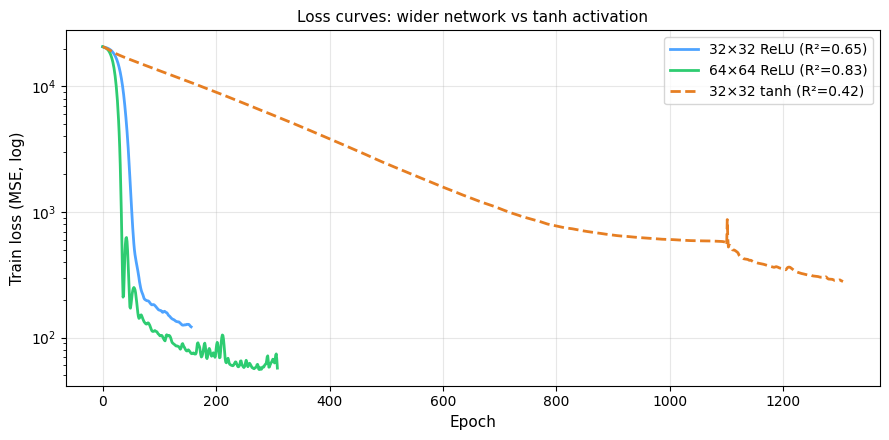

Assertion passed: wider MLP R² (0.834) >= narrow MLP R² - 0.02 (0.631)

Observation: wider network usually converges to a similar R² or slightly better,
but may take more or fewer epochs depending on the random initialisation.


In [9]:
# --- Cell 9: Exercise cell (working version with try-this markers) ---

# ──────────────────────────────────────────────────────────────────────────────
# EXERCISE: change network width and activation
# ──────────────────────────────────────────────────────────────────────────────

# (try this yourself) Step 1: create a wider MLP with ReLU
mlp_wide = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 64),   # (try this yourself) wider layers
        activation='relu',              # (try this yourself) same activation as baseline
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# (try this yourself) Step 2: create a tanh MLP for comparison
mlp_tanh = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(32, 32),
        activation='tanh',              # (try this yourself) tanh activation
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# (try this yourself) Step 3: fit both models on the training data
mlp_wide.fit(X_raw[idx_tr], H_all[idx_tr])
mlp_tanh.fit(X_raw[idx_tr], H_all[idx_tr])

# (try this yourself) Step 4: compute test scores
r2_wide = r2_score(H_all[idx_te], mlp_wide.predict(X_raw[idx_te]))
r2_tanh = r2_score(H_all[idx_te], mlp_tanh.predict(X_raw[idx_te]))

n_ep_wide = len(mlp_wide.named_steps['mlp'].loss_curve_)
n_ep_tanh = len(mlp_tanh.named_steps['mlp'].loss_curve_)

print("Model comparison:")
print(f"  Baseline MLP (32×32, ReLU): R² = {r2_mlp:.3f}  ({n_epochs_trained} epochs)")
print(f"  Wider MLP  (64×64, ReLU):   R² = {r2_wide:.3f}  ({n_ep_wide} epochs)")
print(f"  Tanh MLP   (32×32, tanh):   R² = {r2_tanh:.3f}  ({n_ep_tanh} epochs)")
print()

# (try this yourself) Step 5: plot loss curves for all three
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(mlp_model.named_steps['mlp'].loss_curve_, color='#4ea3ff', lw=2,
            label=f'32×32 ReLU (R²={r2_mlp:.2f})')
ax.semilogy(mlp_wide.named_steps['mlp'].loss_curve_, color='#2ecc71', lw=2,
            label=f'64×64 ReLU (R²={r2_wide:.2f})')
ax.semilogy(mlp_tanh.named_steps['mlp'].loss_curve_, color='#e67e22', lw=2,
            linestyle='--', label=f'32×32 tanh (R²={r2_tanh:.2f})')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Train loss (MSE, log)', fontsize=11)
ax.set_title('Loss curves: wider network vs tanh activation', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (try this yourself) Step 6: assert that the wider ReLU MLP is at least as good as the narrow one
# Allow a small tolerance (0.02) because the networks may converge to similar local minima
assert r2_wide >= r2_mlp - 0.02, (
    f"Wider MLP R² ({r2_wide:.3f}) should be at least as large as the narrow MLP R² ({r2_mlp:.3f}) "
    "minus a small tolerance. If this fails, try increasing max_iter."
)
print(f"Assertion passed: wider MLP R² ({r2_wide:.3f}) >= narrow MLP R² - 0.02 ({r2_mlp - 0.02:.3f})")
print()
print("Observation: wider network usually converges to a similar R² or slightly better,")
print("but may take more or fewer epochs depending on the random initialisation.")

### Solution

```python
# SOLUTION — run after attempting the exercise yourself

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Step 1: wider MLP with ReLU
mlp_wide_sol = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# Step 2: tanh MLP
mlp_tanh_sol = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(32, 32),
        activation='tanh',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# Steps 3-4: fit and score
mlp_wide_sol.fit(X_raw[idx_tr], H_all[idx_tr])
mlp_tanh_sol.fit(X_raw[idx_tr], H_all[idx_tr])

r2_wide_sol = r2_score(H_all[idx_te], mlp_wide_sol.predict(X_raw[idx_te]))
r2_tanh_sol = r2_score(H_all[idx_te], mlp_tanh_sol.predict(X_raw[idx_te]))

print(f"Wider ReLU R²: {r2_wide_sol:.3f}")
print(f"Tanh R²:       {r2_tanh_sol:.3f}")

# Step 6: assertion
assert r2_wide_sol >= r2_mlp - 0.02

# What to observe:
# - Wider network often converges to similar R² — this dataset is not capacity-limited.
# - tanh may converge more slowly at first (saturation slows early gradients)
#   but often reaches similar final performance on small, shallow problems.
# - The loss curve shape tells the story: rapid early drop = healthy gradients.
```

**Key takeaways:**

| Setting | What changes | What to watch |
|---------|-------------|---------------|
| Wider layers (more neurons) | More parameters, more capacity | Might overfit on small $N$; diminishing returns above a threshold |
| `tanh` instead of `relu` | Saturating activation, gradients ≤ 0.25 | Loss may decrease more slowly; final R² often similar for shallow 2-layer nets |
| More layers (deeper) | Stronger expressivity | Vanishing gradient risk increases; ReLU is critical for depth ≥ 4 |

**Coming next (Week 6):**  
Convolutional neural networks — the same MLP logic, with spatial structure built in.  
CNNs are the reason deep learning works on EM images without flattening every pixel.

## Summary

| Step | What you did |
|------|--------------|
| **Synthetic dataset** | Hall–Petch + temperature → hardness; nonlinear in grain size $d$ |
| **Linear baseline** | Ridge on hand-crafted $1/\sqrt{d}$ feature; $R^2 \approx 0.90$ |
| **MLP** | MLPRegressor (32×32 ReLU, Adam) on raw $(d, T)$; $R^2 \approx 0.65$ — linear baseline wins |
| **Loss curve** | Monitored training and validation loss; early stopping at plateau |
| **Visual comparison** | Both models recover the Hall–Petch curve shape |
| **Exercise** | Changed width (64×64) and activation (tanh); observed effect on loss and $R^2$ |

**Key lessons:**
1. An MLP trained on raw features discovers the nonlinear $1/\sqrt{d}$ transformation without being told.
2. With limited data ($N = 225$ training samples), the linear baseline ($R^2 \approx 0.91$) clearly outperforms the small MLP ($R^2 \approx 0.65$). The MLP must discover the $1/\sqrt{d}$ transformation from scratch; at this sample size domain knowledge wins — embed it when you have it.
3. Monitor validation loss, not training loss. Early stopping is free regularisation.
4. ReLU beats tanh for deeper networks because it preserves gradient magnitude.

**Self-study link:** the Week 5 deck explains the perceptron, XOR, MLPs, activation functions, and backprop in detail. The optional self-study file `data_science_for_em/01_intro/01_autograd.qmd` shows how autograd computes gradients in PyTorch.